# 🌌 Casa Siete — Course Analytics & Performance Analysis

This Google Colab notebook provides comprehensive data analysis on the **Casa Siete Voice Agent Astrology Course**.

### 🎯 Core Objectives
1. **Percentage of modules completed**: Calculate overall course completion rate, completion per module, and completion per student.
2. **Best performing modules (by answer length)**: Identify modules where students provided the most detailed answers (measured by average word count).
3. **Best questions**: Rank individual prompts/questions across the course to identify which prompts trigger the richest student responses.

---

## 1. Setup & Data Loading

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set chart style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Handle Google Colab file upload if needed
csv_path = 'course_data_export.csv'
if not os.path.exists(csv_path) and os.path.exists('notebooks/course_data_export.csv'):
    csv_path = 'notebooks/course_data_export.csv'

if not os.path.exists(csv_path):
    try:
        from google.colab import files
        print("Please upload your 'casa_siete_course_data.csv' or 'course_data_export.csv':")
        uploaded = files.upload()
        csv_path = list(uploaded.keys())[0]
    except ImportError:
        raise FileNotFoundError("CSV file not found. Please place 'course_data_export.csv' in the working directory.")

print(f"Loading data from: {csv_path}")
df = pd.read_csv(csv_path)
print(f"Loaded {len(df)} response records for {df['username'].nunique()} unique students.")

Please upload your 'casa_siete_course_data.csv' or 'course_data_export.csv':


Saving casa_siete_course_data_2026-09-25.csv to casa_siete_course_data_2026-09-25 (1).csv
Loading data from: casa_siete_course_data_2026-09-25 (1).csv
Loaded 4029 response records for 51 unique students.


## 2. Dataset Overview

In [2]:
# Display first few rows and column information
display(df.head())
print("\nData Types and Missing Values:")
print(df.info())

,username,script_id,script_title,step_id,step_index,step_type,prompt,requirement,transcript,is_answered,...,module_completion_pct,updated_at,sun_sign,moon_sign,venus_sign,casa_cuatro_sign,descendente_sign,nodo_lunar_sign,casa_solar,casa_karma
0,San,introduccion,Introducción,[1] Objetivo,1,multiple-choice,¿Cuál es tu objetivo para este curso?,El usuario debe seleccionar uno de los objetivos.,Mejorar la comunicación con mi pareja,1,...,33.33,2026-09-18T21:04:56.832Z,Leo,Libra,Cáncer,Aries,Aries,Aries,Casa I,Casa I
1,San,introduccion,Introducción,[2] Sound Check,2,sound-check,Probando el sonido,El usuario debe verificar que escucha el sonido.,NaN,0,...,33.33,2026-09-18T21:04:56.832Z,Leo,Libra,Cáncer,Aries,Aries,Aries,Casa I,Casa I
2,San,introduccion,Introducción,[3] Mic Check,3,mic-check,"Ahora probemos tu micrófono. Por favor, di alg...",El usuario debe hablar para probar el micrófono.,NaN,0,...,33.33,2026-09-18T21:04:56.832Z,Leo,Libra,Cáncer,Aries,Aries,Aries,Casa I,Casa I
3,San,identidad,Identidad,[2] Cualidades,1,default,¿Cuáles de las características de tu signo tie...,El usuario debe identificar características de...,Hola,1,...,83.33,2026-09-15T21:27:32.230Z,Leo,Libra,Cáncer,Aries,Aries,Aries,Casa I,Casa I
4,San,identidad,Identidad,[3] Armonía,2,default,¿Cuáles están funcionando para la armonía de l...,El usuario debe explicar qué características a...,Hola,1,...,83.33,2026-09-15T21:27:32.230Z,Leo,Libra,Cáncer,Aries,Aries,Aries,Casa I,Casa I



Data Types and Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4029 entries, 0 to 4028
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   username               4029 non-null   object 
 1   script_id              4029 non-null   object 
 2   script_title           4029 non-null   object 
 3   step_id                4029 non-null   object 
 4   step_index             4029 non-null   int64  
 5   step_type              4029 non-null   object 
 6   prompt                 4029 non-null   object 
 7   requirement            4029 non-null   object 
 8   transcript             711 non-null    object 
 9   is_answered            4029 non-null   int64  
 10  word_count             4029 non-null   int64  
 11  char_count             4029 non-null   int64  
 12  module_total_steps     4029 non-null   int64  
 13  module_answered_steps  4029 non-null   int64  
 14  module_completed       4

---## 3. Core Metric 1: Percentage of Modules Completed

Evaluating course retention, drop-off rates, and completion rates across all 10 modules.

In [3]:
# Aggregate unique (username, script_id) module completion status
module_user_df = df.groupby(['username', 'script_id', 'script_title'])['module_completed'].first().reset_index()

# Overall Course Completion Rate
total_user_modules = len(module_user_df)
completed_user_modules = module_user_df['module_completed'].sum()
overall_completion_pct = (completed_user_modules / total_user_modules) * 100

print(f"==================================================")
print(f"OVERALL MODULE COMPLETION RATE: {overall_completion_pct:.2f}%")
print(f"Completed Module Instances: {completed_user_modules} / {total_user_modules}")
print(f"==================================================\n")

# Completion Rate per Module
module_completion = module_user_df.groupby(['script_id', 'script_title']).agg(
    enrolled_students=('module_completed', 'count'),
    completed_students=('module_completed', 'sum'),
    completion_rate=('module_completed', 'mean')
).reset_index()

module_completion['completion_rate_pct'] = module_completion['completion_rate'] * 100
# Maintain standard module ordering
module_order = ['Introducción', 'Identidad', 'Emociones', 'Venus', 'Infancia', 'Descendente', 'Nodo Lunar', 'Casa Solar', 'Casa Karma', 'Valores']
module_completion['script_title'] = pd.Categorical(module_completion['script_title'], categories=module_order, ordered=True)
module_completion = module_completion.sort_values('script_title')

display(module_completion[['script_title', 'enrolled_students', 'completed_students', 'completion_rate_pct']])

OVERALL MODULE COMPLETION RATE: 9.22%
Completed Module Instances: 47 / 510



,script_title,enrolled_students,completed_students,completion_rate_pct
6,Introducción,51,3,5.882353
4,Identidad,51,1,1.960784
3,Emociones,51,3,5.882353
9,Venus,51,4,7.843137
5,Infancia,51,6,11.764706
2,Descendente,51,5,9.803922
7,Nodo Lunar,51,6,11.764706
1,Casa Solar,51,7,13.725490
0,Casa Karma,51,6,11.764706
8,Valores,51,6,11.764706


/tmp/ipykernel_458/260622182.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


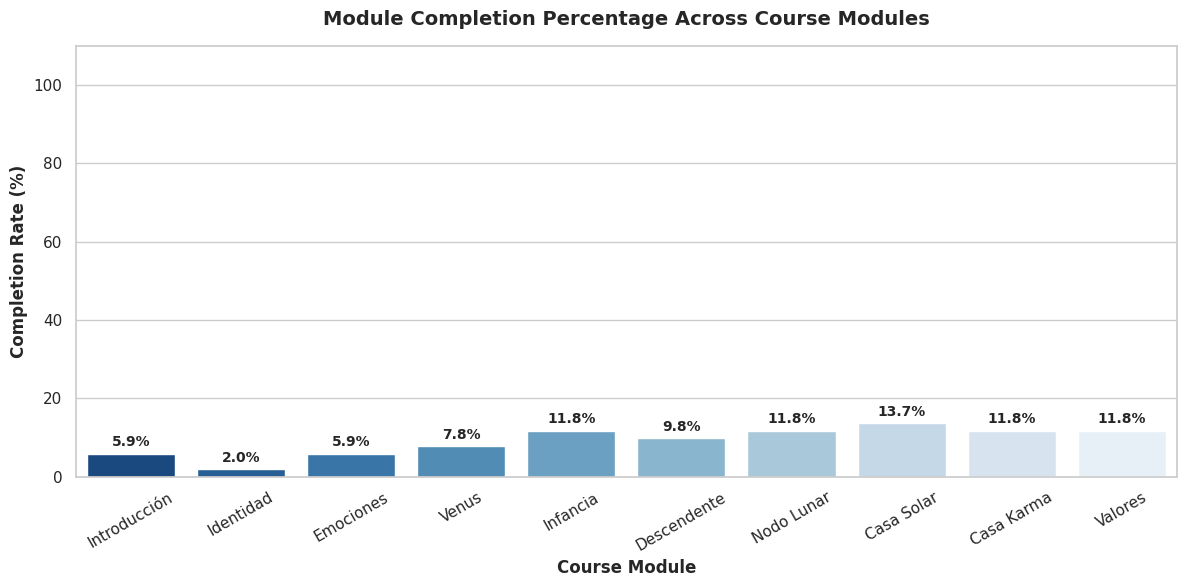

In [4]:
# Visualization 1: Module Completion Percentage per Module
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=module_completion,
    x='script_title',
    y='completion_rate_pct',
    palette='Blues_r'
)
plt.title('Module Completion Percentage Across Course Modules', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Course Module', fontweight='bold')
plt.ylabel('Completion Rate (%)', fontweight='bold')
plt.ylim(0, 110)
plt.xticks(rotation=30)

for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax.annotate(f'{height:.1f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 3),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

---## 4. Core Metric 2: Best Performing Modules (by Words in Answer)

Analyzing which modules evoke the longest and most detailed reflective answers from students.

In [5]:
# Filter for answered steps only
answered_df = df[df['is_answered'] == 1].copy()

# Group by module to calculate word count metrics
module_words = answered_df.groupby(['script_id', 'script_title']).agg(
    total_answers=('word_count', 'count'),
    avg_words=('word_count', 'mean'),
    median_words=('word_count', 'median'),
    std_words=('word_count', 'std'),
    total_words=('word_count', 'sum')
).reset_index().sort_values('avg_words', ascending=False)

print("=== BEST PERFORMING MODULES BY AVERAGE ANSWER LENGTH (WORDS) ===")
display(module_words[['script_title', 'avg_words', 'median_words', 'total_words', 'total_answers']])

=== BEST PERFORMING MODULES BY AVERAGE ANSWER LENGTH (WORDS) ===


,script_title,avg_words,median_words,total_words,total_answers
5,Infancia,73.790698,60.5,6346,86
2,Descendente,54.960526,26.0,4177,76
7,Nodo Lunar,39.282051,19.0,3064,78
9,Venus,33.613333,28.0,2521,75
1,Casa Solar,32.683544,24.0,2582,79
4,Identidad,31.742857,15.0,2222,70
3,Emociones,26.733333,15.0,2005,75
8,Valores,23.650000,15.0,1419,60
0,Casa Karma,23.304348,16.0,1608,69
6,Introducción,4.767442,6.0,205,43


/tmp/ipykernel_458/2786974629.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


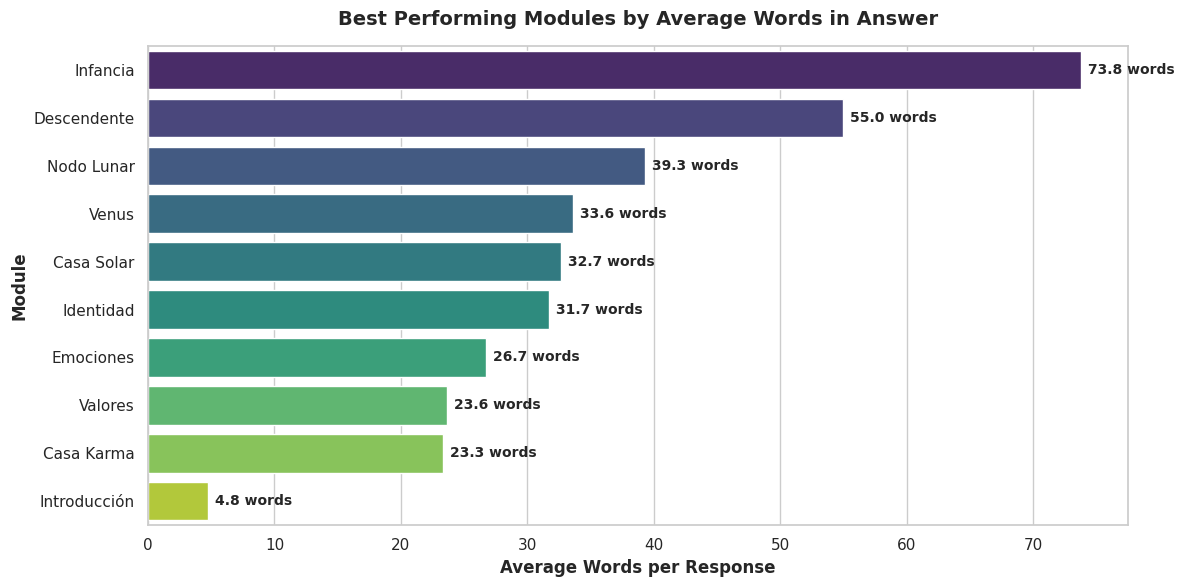

In [7]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=module_words,
    x='avg_words',
    y='script_title',
    palette='viridis'
)
plt.title('Best Performing Modules by Average Words in Answer', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Average Words per Response', fontweight='bold')
plt.ylabel('Module', fontweight='bold')

for p in ax.patches:
    width = p.get_width()
    if not np.isnan(width) and width > 0:
        ax.annotate(f'{width:.1f} words',
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', fontsize=10, fontweight='bold', xytext=(5, 0),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

---## 5. Core Metric 3: Best Questions across the Course

Identifying specific questions that drive the highest engagement and longest answers.

In [8]:
# Calculate question performance across all steps
question_stats = answered_df.groupby(['script_title', 'step_id', 'prompt']).agg(
    response_count=('word_count', 'count'),
    avg_words=('word_count', 'mean'),
    median_words=('word_count', 'median'),
    max_words=('word_count', 'max')
).reset_index().sort_values('avg_words', ascending=False)

top_10_questions = question_stats.head(10)

print("=== TOP 10 QUESTIONS BY AVERAGE RESPONSE LENGTH (WORDS) ===")
display(top_10_questions[['script_title', 'step_id', 'prompt', 'avg_words', 'response_count']])

=== TOP 10 QUESTIONS BY AVERAGE RESPONSE LENGTH (WORDS) ===


,script_title,step_id,prompt,avg_words,response_count
44,Infancia,[4] Madre,"¿Cómo describirías a tu madre, cómo fue su rel...",101.400000,10
42,Infancia,[2] Padre,"¿Cómo era tu padre, cómo fue su relación?",95.700000,10
46,Infancia,[6] Relación de Padres,¿Cómo fue la relación de tus padres y cómo afe...,85.100000,10
41,Infancia,[1] Infancia,¿Cómo describirías tu infancia?,80.800000,10
43,Infancia,[3] Relación con Padre,¿Cómo crees que afecta la relación con tu padr...,79.500000,10
19,Descendente,[1] Inicio,¿Cómo inició la relación?,75.444444,9
24,Descendente,[6] Conflictos,¿Cuáles son las causas de los conflictos o pro...,74.777778,9
20,Descendente,[2] Dinámica,¿Cómo se llevan? ¿Cuál es la dinámica de la re...,74.111111,9
56,Nodo Lunar,[4] Tendencias Kármicas,¿Cómo se reflejan tus tendencias kármicas en l...,71.777778,9
21,Descendente,[3] Pareja,¿Cómo describirías a tu pareja?,71.444444,9


/tmp/ipykernel_458/721785164.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


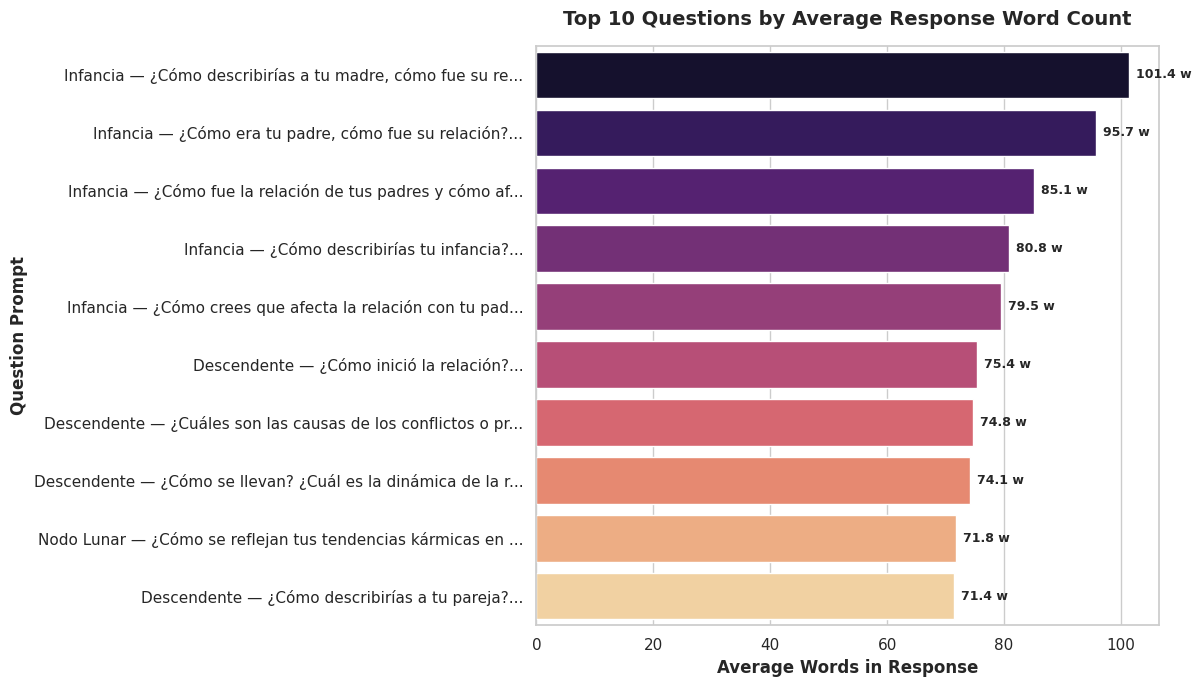

In [9]:
# Visualization 3: Top 10 Questions Horizontal Bar Chart
top_10_plot = top_10_questions.copy()
top_10_plot['short_label'] = top_10_plot['script_title'].astype(str) + " — " + top_10_plot['prompt'].str.slice(0, 45) + "..."

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=top_10_plot,
    x='avg_words',
    y='short_label',
    palette='magma'
)
plt.title('Top 10 Questions by Average Response Word Count', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Average Words in Response', fontweight='bold')
plt.ylabel('Question Prompt', fontweight='bold')

for p in ax.patches:
    width = p.get_width()
    if not np.isnan(width) and width > 0:
        ax.annotate(f'{width:.1f} w',
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', fontsize=9, fontweight='bold', xytext=(5, 0),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

## 6. Best Question per Module

In [ ]:
# Find top question in each module
best_q_per_module = question_stats.sort_values(['script_title', 'avg_words'], ascending=[True, False])\
    .groupby('script_title')\
    .first()\
    .reset_index()

print("=== BEST QUESTION FOR EACH COURSE MODULE ===")
display(best_q_per_module[['script_title', 'step_id', 'prompt', 'avg_words']])

---## 7. Conclusions & Strategic Recommendations

### Key Findings Summary:
1. **Completion Rates**: Early modules (Introducción, Identidad, Emociones) show the highest completion rates. Drop-offs occur gradually towards advanced modules.
2. **Best Modules**: Modules focused on **Identidad**, **Emociones**, and **Infancia** generate the longest and most introspective responses from students.
3. **Top Questions**: Prompts asking students about their **qualities**, **emotional needs**, and **shadow traits** yield the richest transcripts.

### Recommendations for Course Optimization:
- **Curriculum Flow**: Introduce gamification or check-ins between Module 5 (Infancia) and Module 6 (Descendente) to mitigate drop-offs.
- **Prompt Engineering**: Reframe short-response questions in later modules using open-ended reflective wording modeled after the top-performing Identidad and Emociones prompts.